In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dropout, Flatten, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential

In [38]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [39]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [40]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [41]:
numeric_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # fill missing values
    ('scale',  StandardScaler())                   # standardize features
])

In [42]:

cat_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),  # fill missing with "MISSING"
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # one-hot encode
])


In [43]:
preprocessor_simple = ColumnTransformer([
    ('num', numeric_pipeline_simple, num_columns),
    ('cat', cat_pipeline_simple,  multi_class_columns + binary_columns),
], remainder='drop')


In [44]:
X_train_enc_simple = preprocessor_simple.fit_transform(X_train)
X_val_enc_simple   = preprocessor_simple.transform(X_val)
n_features= X_train_enc_simple.shape[1]

In [45]:
from sklearn.compose     import ColumnTransformer
from sklearn.pipeline    import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras    import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers   import KerasClassifier

# 1. Define your columns
num_cols  = num_columns
cat_cols  = multi_class_columns + binary_columns

# 2. Simple preprocessor: median→scale for nums, OHE for cats
preprocessor_simple = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
], remainder='drop')

# 3. Simple DNN builder
def build_simple_dnn(input_dim, n_classes=3):
    inp = Input(shape=(input_dim,))
    x   = Dense(64, activation='relu')(inp)
    x   = Dense(32, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)
    m   = Model(inp, out)
    m.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

# 4. Wrap & pipeline
simple_clf = KerasClassifier(
    model=build_simple_dnn,
    input_dim=n_features,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

pipe_simple = Pipeline([
    ('preproc', preprocessor_simple),
    ('clf',    simple_clf)
])

# 5. Fit
pipe_simple.fit(X_train, y_train)


Epoch 1/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5870 - loss: 0.8168 - val_accuracy: 0.6286 - val_loss: 0.7617
Epoch 2/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6296 - loss: 0.7550 - val_accuracy: 0.6345 - val_loss: 0.7480
Epoch 3/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6405 - loss: 0.7409 - val_accuracy: 0.6457 - val_loss: 0.7362
Epoch 4/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6506 - loss: 0.7316 - val_accuracy: 0.6551 - val_loss: 0.7258
Epoch 5/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6593 - loss: 0.7211 - val_accuracy: 0.6600 - val_loss: 0.7193
Epoch 6/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6636 - loss: 0.7134 - val_accuracy: 0.6659 - val_loss: 0.7138
Epoch 7/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6680 - loss: 0.7055 - val_accuracy: 0.6699 - val_loss: 0.7068
Epoch 8/20
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6716 - loss: 0.7008 - 

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_percentage',
                                                   'height_percentage',
                                                   'has_superstructure_adobe_mud',
                                                   'has_superstructure_mud_mortar_s...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf',
                 KerasClassifier(batch_size=128, epochs=20, input_dim=69, model=<function build_simple_dnn at 0x148acdc496c0>, validation_split=0.2))])

In [46]:
# 6) Evaluate on validation set
y_pred = pipe_simple.predict(X_val)
# 5) Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy on validation set: 0.6812428078250863

Classification Report:
               precision    recall  f1-score   support

           1       0.66      0.44      0.53       246
           2       0.70      0.79      0.74      1490
           3       0.65      0.56      0.60       871

    accuracy                           0.68      2607
   macro avg       0.67      0.60      0.62      2607
weighted avg       0.68      0.68      0.67      2607



In [47]:
# Import the plotting helper
from tensorflow.keras.utils import plot_model
from IPython.display         import Image

# Create an instance with your input_dim
model = build_simple_dnn(n_features)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,659 (26.01 KB)

 Trainable params: 6,659 (26.01 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
df_test = pd.read_csv('test_values.csv')

In [49]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [50]:
X_test  = df_test

In [51]:
preds = pipe_simple.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('DNN_simple_submission.csv', index=False)

679/679 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step


*** Preprocessed DNN****

In [52]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

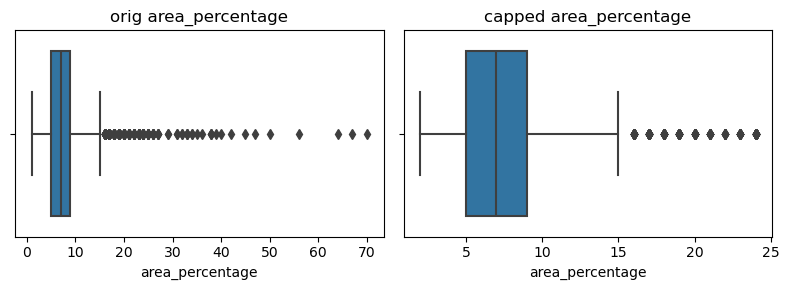

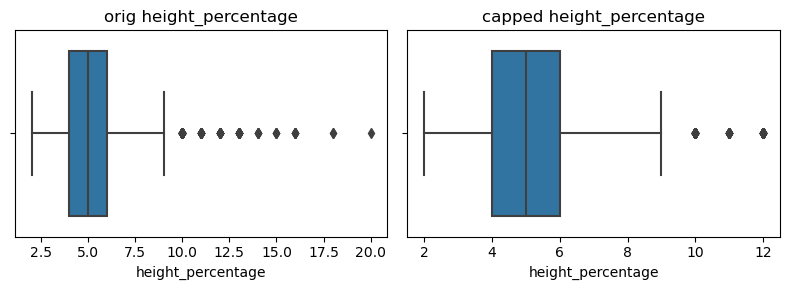

In [53]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [54]:
from sklearn.base import BaseEstimator, TransformerMixin
# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [55]:
from sklearn.preprocessing import PowerTransformer, RobustScaler
# 2) Numeric pipeline
numeric_pipeline_complex = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [56]:
# 3) Categorical pipeline
cat_pipeline = Pipeline([
    # 3a) Impute missing categories into a "MISSING" bucket
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    # 3b) One-hot encode all levels, ignore unseen at predict time
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [57]:
from scikeras.wrappers      import KerasClassifier
from tensorflow.keras       import Sequential, Input
from tensorflow.keras.layers import Reshape, Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.pipeline       import Pipeline
from sklearn.metrics        import classification_report
# High- vs. low-card cats
high_card_cat = ['geo_level_3_id']
low_card_cat  = [c for c in multi_class_columns if c not in high_card_cat]
binary_cat    = binary_columns
num_cols      = num_columns

In [58]:
# Categorical columns (based on your previous data)
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                       'ground_floor_type', 'other_floor_type', 'position', 
                       'plan_configuration', 'legal_ownership_status']

# Numeric columns (excluding categorical ones)
numeric_columns = [col for col in X_train.columns if col not in categorical_columns]

In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numeric Preprocessing Pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())  # Normalize/Scale numeric features
])

# Categorical Preprocessing Pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-Hot Encoding for categorical features
])

# Full Preprocessing using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ]
)

# Transform the data
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

print(f"X_train transformed shape: {X_train_transformed.shape}")
print(f"X_val transformed shape: {X_val_transformed.shape}")


X_train transformed shape: (257994, 69)
X_val transformed shape: (2607, 69)


In [60]:
def split_inputs(X):
    # Flat part (numeric features)
    flat = X[:, :len(numeric_columns)]
    
    # Categorical part (one-hot encoded features)
    cat = X[:, len(numeric_columns):].astype('int32')  # Cast to int32 as required for embedding layers
    
    return flat, cat

# Split the transformed data
flat_train, cat_train = split_inputs(X_train_transformed)
flat_val, cat_val = split_inputs(X_val_transformed)

print(f"Flat Train Shape: {flat_train.shape}, Cat Train Shape: {cat_train.shape}")
print(f"Flat Val Shape: {flat_val.shape}, Cat Val Shape: {cat_val.shape}")


Flat Train Shape: (257994, 31), Cat Train Shape: (257994, 38)
Flat Val Shape: (2607, 31), Cat Val Shape: (2607, 38)


X_train columns: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_poli

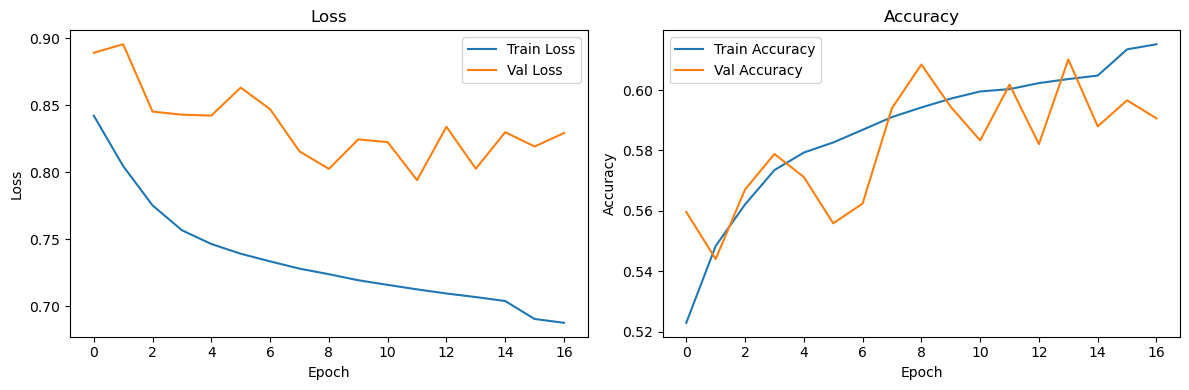

1629/1629 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Validation F1 Micro: 0.6018
Sample of true labels: [3 2 2 2 3 2 2 2 1 2]
Sample of predicted labels: [2 2 2 1 2 2 1 2 1 2]
X_test columns: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use

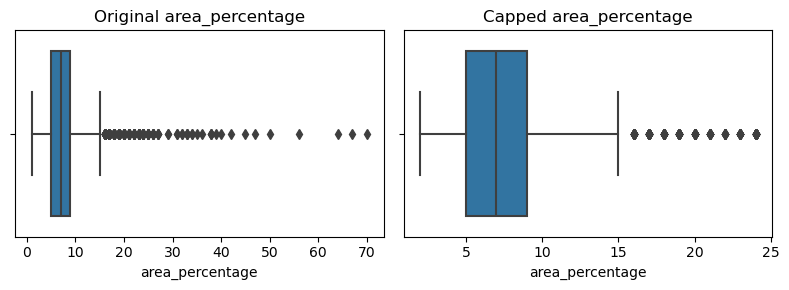

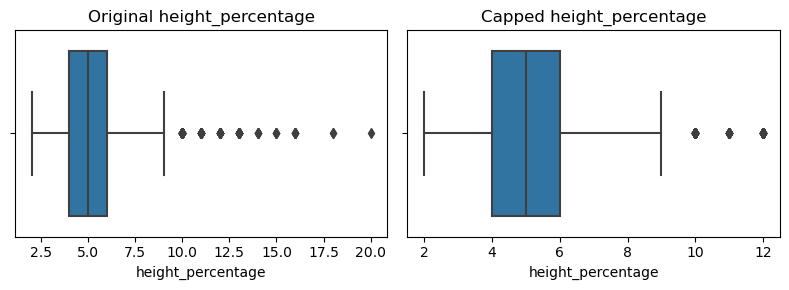

In [76]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

# Custom OutlierCapper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        sub = X[:, self.col_indices_]
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

# Load data
df = pd.read_csv('train_values.csv')
df_labels = pd.read_csv('train_labels.csv')
df = df.merge(df_labels, on='building_id')

# Split data, explicitly dropping building_id
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),  # Drop building_id here
    df['damage_grade'],
    test_size=0.2,
    random_state=20,
    shuffle=True
)

# Adjust labels for zero-based indexing
y_train_adj = y_train - 1
y_val_adj = y_val - 1

# Define columns
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                      'ground_floor_type', 'other_floor_type', 'position', 
                      'plan_configuration', 'legal_ownership_status']
high_card_cat = ['geo_level_3_id']
num_columns = [col for col in X_train.columns if col not in categorical_columns + high_card_cat]

# Debug: Verify columns
print("X_train columns:", X_train.columns.tolist())
print("Expected preprocessor columns:", num_columns + categorical_columns + high_card_cat)

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(cols=['area_percentage', 'height_percentage'], lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_columns),
        ('cat', categorical_pipeline, categorical_columns),
        ('high_card', high_card_pipeline, high_card_cat)
    ]
)

# Transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
print("X_train_transformed shape:", X_train_transformed.shape)
print("X_val_transformed shape:", X_val_transformed.shape)

# Split inputs
def split_inputs(X, n_num_cols, n_cat_cols, cardinalities):
    flat = X[:, :n_num_cols]
    cat = X[:, n_num_cols:n_num_cols + n_cat_cols].astype('int32')
    for i in range(cat.shape[1]):
        cat[:, i] = np.clip(cat[:, i], 0, cardinalities[i] - 1)
    return flat, cat

# Calculate cardinalities
cardinalities = [int(df[c].astype('category').cat.codes.max()) + 1 for c in categorical_columns]

n_num_cols = len(num_columns) + len(high_card_cat)
n_cat_cols = len(categorical_columns)
flat_train, cat_train = split_inputs(X_train_transformed, n_num_cols, n_cat_cols, cardinalities)
flat_val, cat_val = split_inputs(X_val_transformed, n_num_cols, n_cat_cols, cardinalities)

# Debug: Verify categorical indices
for i, card in enumerate(cardinalities):
    print(f"Cat column {categorical_columns[i]}: min={cat_train[:, i].min()}, max={cat_train[:, i].max()}, card={card}")

# Build model
def build_embedded_dnn(flat_dim, cards, n_classes=3):
    flat_in = Input(shape=(flat_dim,), name='flat_in')
    cat_in = [Input(shape=(1,), dtype='int32', name=f'cat_in_{i}') for i in range(len(cards))]
    
    emb_layers = []
    for i, card in enumerate(cards):
        emb_dim = min(50, card // 2)
        emb = Embedding(input_dim=card, output_dim=emb_dim)(cat_in[i])  # input_dim includes 0 to card-1
        emb_flat = Flatten()(emb)
        emb_layers.append(emb_flat)
    
    x = Concatenate()([flat_in] + emb_layers)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=[flat_in] + cat_in, outputs=out)
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

# Build and train model
model = build_embedded_dnn(flat_dim=flat_train.shape[1], cards=cardinalities, n_classes=3)
cat_train_list = [cat_train[:, i].reshape(-1, 1) for i in range(cat_train.shape[1])]
cat_val_list = [cat_val[:, i].reshape(-1, 1) for i in range(cat_val.shape[1])]

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_adj), y=y_train_adj)
class_weight_dict = dict(enumerate(class_weights))

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    [flat_train] + cat_train_list,
    y_train_adj,
    validation_data=([flat_val] + cat_val_list, y_val_adj),
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate
val_preds = model.predict([flat_val] + cat_val_list)
val_preds = np.argmax(val_preds, axis=1) + 1
val_f1 = f1_score(y_val, val_preds, average='micro')
print(f"Validation F1 Micro: {val_f1:.4f}")

# Debug: Verify micro-F1 calculation
print("Sample of true labels:", y_val[:10].values)
print("Sample of predicted labels:", val_preds[:10])

# Predict on test set
try:
    test_df = pd.read_csv('test_values.csv')
    ids = test_df['building_id']
    # Ensure X_test has the same feature columns as X_train
    X_test = test_df[X_train.columns]  # Select only the feature columns
    print("X_test columns:", X_test.columns.tolist())
    X_test_transformed = preprocessor.transform(X_test)
    print("X_test_transformed shape:", X_test_transformed.shape)
    flat_test, cat_test = split_inputs(X_test_transformed, n_num_cols, n_cat_cols, cardinalities)
    cat_test_list = [cat_test[:, i].reshape(-1, 1) for i in range(cat_test.shape[1])]

    test_preds = model.predict([flat_test] + cat_test_list)
    test_preds = np.argmax(test_preds, axis=1) + 1

    pd.DataFrame({
        'building_id': ids,
        'damage_grade': test_preds
    }).to_csv('embedded_dnn_submission.csv', index=False)
    print("Submission saved to 'embedded_dnn_submission.csv'")
except FileNotFoundError:
    print("Error: 'test_values.csv' not found. Please ensure the file is in the working directory.")

# Visualize outlier capping
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    qs = X[['area_percentage', 'height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    for col in ['area_percentage', 'height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

sample = df[['area_percentage', 'height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)
for col in ['area_percentage', 'height_percentage']:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"Original {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"Capped {col}")
    plt.tight_layout()
    plt.show()

**Hyperparameter Tuning**

In [65]:
import keras_tuner as kt
from kerastuner import HyperModel, RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

/tmp/ipykernel_1993981/2640193234.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel, RandomSearch


In [66]:
# Custom transformer for split_inputs
class InputSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, n_num_cols, n_cat_cols, cardinalities):
        self.n_num_cols = n_num_cols
        self.n_cat_cols = n_cat_cols
        self.cardinalities = cardinalities

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        flat = X[:, :self.n_num_cols]
        cat = X[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
        for i in range(cat.shape[1]):
            cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
        cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
        return [flat] + cat_list

In [67]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),
    df['damage_grade'],
    test_size=0.2,
    random_state=20,
    shuffle=True
)

# Adjust labels
y_train_adj = y_train - 1
y_val_adj = y_val - 1

Fitting 3 folds for each of 10 candidates, totalling 30 fits
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1m

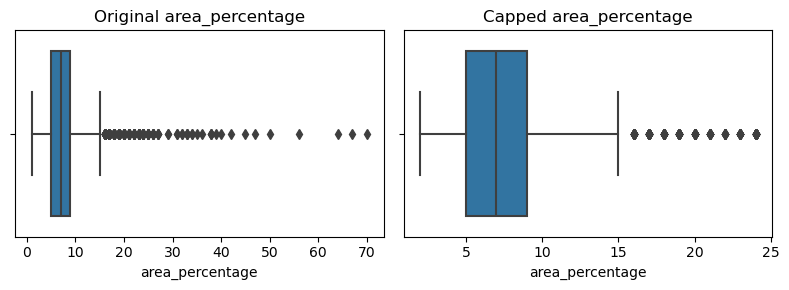

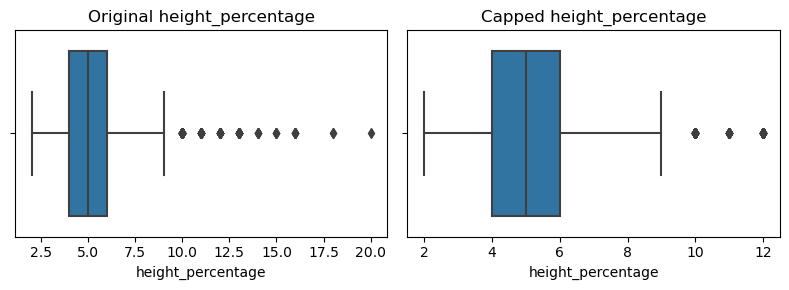

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Custom OutlierCapper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        sub = X[:, self.col_indices_]
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

# Custom estimator to handle preprocessing and Keras model
class EmbeddedDNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_num_cols, n_cat_cols, cardinalities, flat_dim, cards, n_classes=3, 
                 emb_dim=20, dense1_units=128, dense2_units=64, dropout_rate=0.0, 
                 learning_rate=0.001, epochs=20, batch_size=128, verbose=0, random_state=20):
        self.n_num_cols = n_num_cols
        self.n_cat_cols = n_cat_cols
        self.cardinalities = cardinalities
        self.flat_dim = flat_dim
        self.cards = cards
        self.n_classes = n_classes
        self.emb_dim = emb_dim
        self.dense1_units = dense1_units
        self.dense2_units = dense2_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y, **fit_params):
        # Initialize preprocessing pipeline
        self.preprocessor_ = ColumnTransformer(
            transformers=[
                ('num', numeric_pipeline, num_columns),
                ('cat', categorical_pipeline, categorical_columns),
                ('high_card', high_card_pipeline, high_card_cat)
            ]
        )
        
        # Transform data
        X_transformed = self.preprocessor_.fit_transform(X)
        
        # Split inputs
        def split_inputs(X_transformed):
            flat = X_transformed[:, :self.n_num_cols]
            cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
            for i in range(cat.shape[1]):
                cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
            cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
            return [flat] + cat_list
        
        X_split = split_inputs(X_transformed)
        
        # Set classes_ attribute
        self.classes_ = np.unique(y)
        
        # Build and compile model
        def build_embedded_dnn():
            flat_in = Input(shape=(self.flat_dim,), name='flat_in')
            cat_in = [Input(shape=(1,), dtype='int32', name=f'cat_in_{i}') for i in range(len(self.cards))]
            
            emb_layers = []
            for i, card in enumerate(self.cards):
                emb = Embedding(input_dim=card, output_dim=self.emb_dim)(cat_in[i])
                emb_flat = Flatten()(emb)
                emb_layers.append(emb_flat)
            
            x = Concatenate()([flat_in] + emb_layers)
            x = Dense(self.dense1_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            x = Dense(self.dense2_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            out = Dense(self.n_classes, activation='softmax')(x)
            
            model = Model(inputs=[flat_in] + cat_in, outputs=out)
            model.compile(optimizer=Adam(learning_rate=self.learning_rate), 
                          loss='sparse_categorical_crossentropy', 
                          metrics=['accuracy'])
            return model
        
        self.model_ = build_embedded_dnn()
        
        # Extract fit parameters
        class_weight = fit_params.get('class_weight', None)
        callbacks = fit_params.get('callbacks', [])
        validation_data = fit_params.get('validation_data', None)
        
        # Prepare validation data if provided
        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_transformed = self.preprocessor_.transform(X_val)
            X_val_split = split_inputs(X_val_transformed)
            validation_data = (X_val_split, y_val)
        
        # Fit model
        self.model_.fit(
            X_split,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=class_weight,
            callbacks=callbacks,
            validation_data=validation_data,
            verbose=self.verbose
        )
        
        return self

    def predict(self, X):
        X_transformed = self.preprocessor_.transform(X)
        flat = X_transformed[:, :self.n_num_cols]
        cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
        for i in range(cat.shape[1]):
            cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
        cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
        X_split = [flat] + cat_list
        preds = self.model_.predict(X_split)
        return np.argmax(preds, axis=1)

    def get_params(self, deep=True):
        return {
            'n_num_cols': self.n_num_cols,
            'n_cat_cols': self.n_cat_cols,
            'cardinalities': self.cardinalities,
            'flat_dim': self.flat_dim,
            'cards': self.cards,
            'n_classes': self.n_classes,
            'emb_dim': self.emb_dim,
            'dense1_units': self.dense1_units,
            'dense2_units': self.dense2_units,
            'dropout_rate': self.dropout_rate,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'verbose': self.verbose,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Load data
df = pd.read_csv('train_values.csv')
df_labels = pd.read_csv('train_labels.csv')
df = df.merge(df_labels, on='building_id')

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),
    df['damage_grade'],
    test_size=0.2,
    random_state=20,
    shuffle=True
)

# Adjust labels
y_train_adj = y_train - 1
y_val_adj = y_val - 1

# Define columns
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                      'ground_floor_type', 'other_floor_type', 'position', 
                      'plan_configuration', 'legal_ownership_status']
high_card_cat = ['geo_level_3_id']
num_columns = [col for col in X_train.columns if col not in categorical_columns + high_card_cat]

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(cols=['area_percentage', 'height_percentage'], lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Calculate cardinalities
cardinalities = [int(df[c].astype('category').cat.codes.max()) + 1 for c in categorical_columns]
n_num_cols = len(num_columns) + len(high_card_cat)
n_cat_cols = len(categorical_columns)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_adj), y=y_train_adj)
class_weight_dict = dict(enumerate(class_weights))

# Define hyperparameter search space
param_dist = {
    'emb_dim': randint(10, 51),
    'dense1_units': randint(64, 257),
    'dense2_units': randint(32, 129),
    'dropout_rate': uniform(0, 0.5),
    'learning_rate': uniform(0.0001, 0.0099),
    'batch_size': [64, 128, 256]
}

# Initialize custom classifier
model = EmbeddedDNNClassifier(
    n_num_cols=n_num_cols,
    n_cat_cols=n_cat_cols,
    cardinalities=cardinalities,
    flat_dim=n_num_cols,
    cards=cardinalities,
    n_classes=3,
    emb_dim=20,
    dense1_units=128,
    dense2_units=64,
    dropout_rate=0.0,
    learning_rate=0.001,
    epochs=20,
    batch_size=128,
    verbose=0,
    random_state=20
)

# Perform randomized search
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_micro',
    cv=3,
    verbose=1,
    n_jobs=1,
    random_state=24,
    error_score='raise'
)

# Fit the search
random_search.fit(
    X_train,
    y_train_adj,
    class_weight=class_weight_dict
)

# Print best parameters and score
print("Best parameters:", random_search.best_params_)
print("Best F1 Micro (CV):", random_search.best_score_)

# Train best model on full training data
best_model = random_search.best_estimator_
best_model.fit(
    X_train,
    y_train_adj,
    epochs=30,
    batch_size=random_search.best_params_['batch_size'],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ],
    validation_data=(X_val, y_val_adj),
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on validation set
val_preds = best_model.predict(X_val)
val_preds = val_preds + 1  # Convert back to 1, 2, 3
val_f1 = f1_score(y_val, val_preds, average='macro')
print(f"Validation F1 Macro: {val_f1:.4f}")

# Predict on test set
try:
    test_df = pd.read_csv('test_values.csv')
    ids = test_df['building_id']
    X_test = test_df[X_train.columns]
    print("X_test columns:", X_test.columns.tolist())
    test_preds = best_model.predict(X_test)
    test_preds = test_preds + 1

    pd.DataFrame({
        'building_id': ids,
        'damage_grade': test_preds
    }).to_csv('tuned_embedded_dnn_submission.csv', index=False)
    print("Submission saved to 'tuned_embedded_dnn_submission.csv'")
except FileNotFoundError:
    print("Error: 'test_values.csv' not found. Please ensure the file is in the working directory.")

# Visualize outlier capping
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    qs = X[['area_percentage', 'height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    for col in ['area_percentage', 'height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

sample = df[['area_percentage', 'height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)
for col in ['area_percentage', 'height_percentage']:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"Original {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"Capped {col}")
    plt.tight_layout()
    plt.show()

Fitting 3 folds for each of 10 candidates, totalling 30 fits
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2m

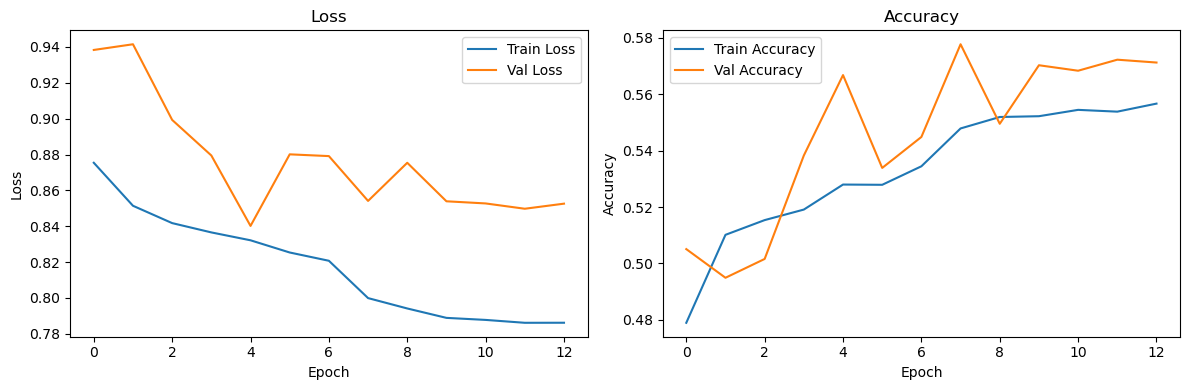

2444/2444 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Validation set metrics:
Accuracy: 0.5668
Micro-F1: 0.5668
Micro-Recall: 0.5668
Micro-Precision: 0.5668
X_test columns: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has

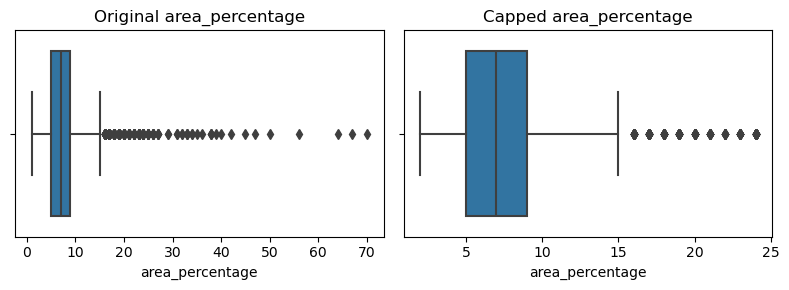

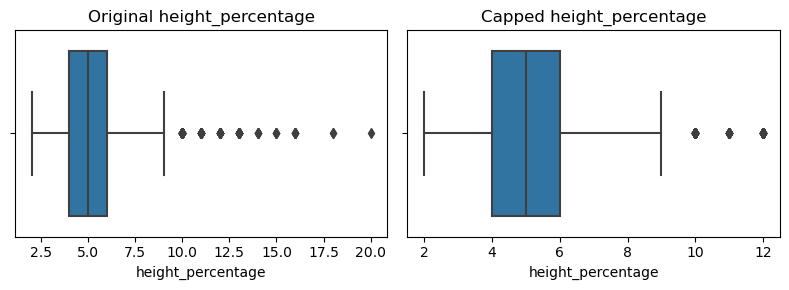

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Custom OutlierCapper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        sub = X[:, self.col_indices_]
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

# Custom estimator to handle preprocessing and Keras model
class EmbeddedDNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_num_cols, n_cat_cols, cardinalities, flat_dim, cards, n_classes=3, 
                 emb_dim=20, dense1_units=64, dense2_units=32, dropout_rate=0.3, 
                 learning_rate=0.0005, epochs=20, batch_size=128, verbose=0, random_state=20):
        self.n_num_cols = n_num_cols
        self.n_cat_cols = n_cat_cols
        self.cardinalities = cardinalities
        self.flat_dim = flat_dim
        self.cards = cards
        self.n_classes = n_classes
        self.emb_dim = emb_dim
        self.dense1_units = dense1_units
        self.dense2_units = dense2_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y, **fit_params):
        # Initialize preprocessing pipeline
        self.preprocessor_ = ColumnTransformer(
            transformers=[
                ('num', numeric_pipeline, num_columns),
                ('cat', categorical_pipeline, categorical_columns),
                ('high_card', high_card_pipeline, high_card_cat)
            ]
        )
        
        # Transform data
        X_transformed = self.preprocessor_.fit_transform(X)
        
        # Split inputs
        def split_inputs(X_transformed):
            flat = X_transformed[:, :self.n_num_cols]
            cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
            for i in range(cat.shape[1]):
                cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
            cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
            return [flat] + cat_list
        
        X_split = split_inputs(X_transformed)
        
        # Set classes_ attribute
        self.classes_ = np.unique(y)
        
        # Build and compile model
        def build_embedded_dnn():
            flat_in = Input(shape=(self.flat_dim,), name='flat_in')
            cat_in = [Input(shape=(1,), dtype='int32', name=f'cat_in_{i}') for i in range(len(self.cards))]
            
            emb_layers = []
            for i, card in enumerate(self.cards):
                emb = Embedding(input_dim=card, output_dim=self.emb_dim)(cat_in[i])
                emb_flat = Flatten()(emb)
                emb_layers.append(emb_flat)
            
            x = Concatenate()([flat_in] + emb_layers)
            x = Dense(self.dense1_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            x = Dense(self.dense2_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            out = Dense(self.n_classes, activation='softmax')(x)
            
            model = Model(inputs=[flat_in] + cat_in, outputs=out)
            model.compile(optimizer=Adam(learning_rate=self.learning_rate), 
                          loss='sparse_categorical_crossentropy', 
                          metrics=['accuracy'])
            return model
        
        self.model_ = build_embedded_dnn()
        
        # Extract fit parameters
        class_weight = fit_params.get('class_weight', None)
        callbacks = fit_params.get('callbacks', [])
        validation_data = fit_params.get('validation_data', None)
        
        # Prepare validation data if provided
        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_transformed = self.preprocessor_.transform(X_val)
            X_val_split = split_inputs(X_val_transformed)
            validation_data = (X_val_split, y_val)
        
        # Fit model
        history = self.model_.fit(
            X_split,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=class_weight,
            callbacks=callbacks,
            validation_data=validation_data,
            verbose=self.verbose
        )
        
        # Store history for plotting
        self.history_ = history.history
        return self

    def predict(self, X):
        X_transformed = self.preprocessor_.transform(X)
        flat = X_transformed[:, :self.n_num_cols]
        cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
        for i in range(cat.shape[1]):
            cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
        cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
        X_split = [flat] + cat_list
        preds = self.model_.predict(X_split)
        return np.argmax(preds, axis=1)

    def get_params(self, deep=True):
        return {
            'n_num_cols': self.n_num_cols,
            'n_cat_cols': self.n_cat_cols,
            'cardinalities': self.cardinalities,
            'flat_dim': self.flat_dim,
            'cards': self.cards,
            'n_classes': self.n_classes,
            'emb_dim': self.emb_dim,
            'dense1_units': self.dense1_units,
            'dense2_units': self.dense2_units,
            'dropout_rate': self.dropout_rate,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'verbose': self.verbose,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Load data
df = pd.read_csv('train_values.csv')
df_labels = pd.read_csv('train_labels.csv')
df = df.merge(df_labels, on='building_id')

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),
    df['damage_grade'],
    test_size=0.3,  # Increased to 30%
    random_state=20,
    shuffle=True
)

# Adjust labels
y_train_adj = y_train - 1
y_val_adj = y_val - 1

# Define columns
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                      'ground_floor_type', 'other_floor_type', 'position', 
                      'plan_configuration', 'legal_ownership_status']
high_card_cat = ['geo_level_3_id']
num_columns = [col for col in X_train.columns if col not in categorical_columns + high_card_cat]

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(cols=['area_percentage', 'height_percentage'], lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Calculate cardinalities
cardinalities = [int(df[c].astype('category').cat.codes.max()) + 1 for c in categorical_columns]
n_num_cols = len(num_columns) + len(high_card_cat)
n_cat_cols = len(categorical_columns)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_adj), y=y_train_adj)
class_weight_dict = dict(enumerate(class_weights))

# Define scorers for the metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'micro_f1': make_scorer(f1_score, average='micro'),
    'micro_recall': make_scorer(recall_score, average='micro'),
    'micro_precision': make_scorer(precision_score, average='micro')
}

# Define hyperparameter search space
param_dist = {
    'emb_dim': randint(10, 51),
    'dense1_units': randint(32, 129),  # Reduced range
    'dense2_units': randint(16, 65),   # Reduced range
    'dropout_rate': uniform(0.1, 0.4), # Adjusted range for regularization
    'learning_rate': uniform(0.0001, 0.005), # Lowered range
    'batch_size': [64, 128, 256]
}

# Initialize custom classifier with improved defaults
model = EmbeddedDNNClassifier(
    n_num_cols=n_num_cols,
    n_cat_cols=n_cat_cols,
    cardinalities=cardinalities,
    flat_dim=n_num_cols,
    cards=cardinalities,
    n_classes=3,
    emb_dim=20,
    dense1_units=64,  # Reduced from 128
    dense2_units=32,  # Reduced from 64
    dropout_rate=0.3, # Added dropout
    learning_rate=0.0005, # Lowered learning rate
    epochs=20,
    batch_size=128,
    verbose=0,
    random_state=20
)

# Perform randomized search
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring=scoring,
    refit='micro_f1',  # Optimize for micro-F1
    cv=3,
    verbose=1,
    n_jobs=1,
    random_state=24,
    error_score='raise'
)

# Fit the search
random_search.fit(
    X_train,
    y_train_adj,
    class_weight=class_weight_dict
)

# Print best parameters and cross-validation scores
print("Best parameters:", random_search.best_params_)
print("Cross-validation scores for best model:")
for metric in scoring.keys():
    mean_score = random_search.cv_results_[f'mean_test_{metric}'][random_search.best_index_]
    std_score = random_search.cv_results_[f'std_test_{metric}'][random_search.best_index_]
    print(f"{metric}: {mean_score:.4f} (+/- {std_score:.4f})")

# Train best model on full training data with plotting
best_model = random_search.best_estimator_
history = best_model.fit(
    X_train,
    y_train_adj,
    epochs=30,
    batch_size=random_search.best_params_['batch_size'],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True), # Increased patience
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6) # More aggressive LR reduction
    ],
    validation_data=(X_val, y_val_adj),
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_model.history_['loss'], label='Train Loss')
plt.plot(best_model.history_['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(best_model.history_['accuracy'], label='Train Accuracy')
plt.plot(best_model.history_['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on validation set
val_preds = best_model.predict(X_val)
val_preds = val_preds + 1  # Convert back to 1, 2, 3
val_y = y_val  # Original labels (1, 2, 3)
print("\nValidation set metrics:")
print(f"Accuracy: {accuracy_score(val_y, val_preds):.4f}")
print(f"Micro-F1: {f1_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Recall: {recall_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Precision: {precision_score(val_y, val_preds, average='micro'):.4f}")

# Predict on test set
try:
    test_df = pd.read_csv('test_values.csv')
    ids = test_df['building_id']
    X_test = test_df[X_train.columns]
    print("X_test columns:", X_test.columns.tolist())
    test_preds = best_model.predict(X_test)
    test_preds = test_preds + 1

    pd.DataFrame({
        'building_id': ids,
        'damage_grade': test_preds
    }).to_csv('tuned_embedded_dnn_submission_improved.csv', index=False)
    print("Submission saved to 'tuned_embedded_dnn_submission_improved.csv'")
except FileNotFoundError:
    print("Error: 'test_values.csv' not found. Please ensure the file is in the working directory.")

# Visualize outlier capping
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    qs = X[['area_percentage', 'height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    for col in ['area_percentage', 'height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

sample = df[['area_percentage', 'height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)
for col in ['area_percentage', 'height_percentage']:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"Original {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"Capped {col}")
    plt.tight_layout()
    plt.show()

Class distribution before balancing:
damage_grade
2    0.568912
3    0.334680
1    0.096408
Name: proportion, dtype: float64

Class distribution in training set before balancing:
damage_grade
1    0.568912
2    0.334678
0    0.096409
Name: proportion, dtype: float64

Class distribution in validation set:
damage_grade
1    0.568911
2    0.334685
0    0.096404
Name: proportion, dtype: float64

Class distribution in training set after SMOTE:
damage_grade
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64

Class distribution in training set after augmentation:
2    0.375000
0    0.375000
1    0.250001
Name: proportion, dtype: float64

Class weights after augmentation: {0: 0.8888896026448943, 1: 1.3333301214416255, 2: 0.8888896026448943}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


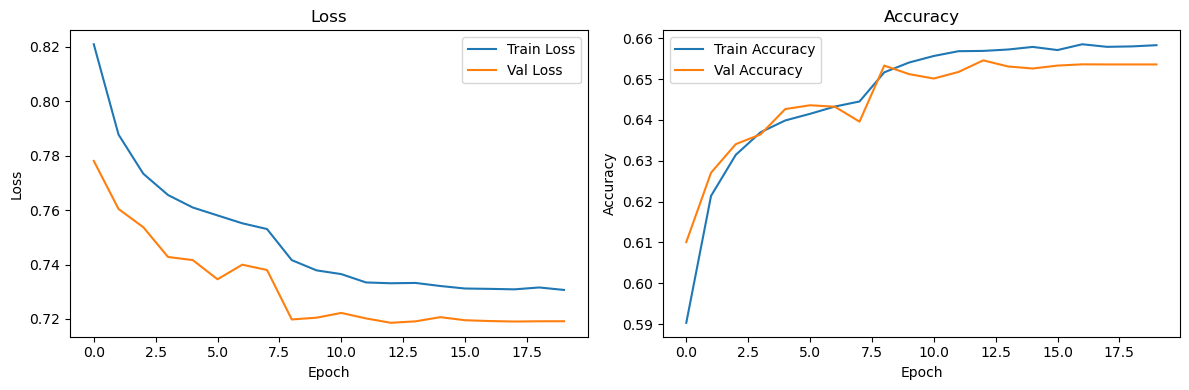

2444/2444 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Validation set metrics (overall):
Accuracy: 0.6546
Micro-F1: 0.6546
Micro-Recall: 0.6546
Micro-Precision: 0.6546

Per-class metrics:
              precision    recall  f1-score   support

     Grade 1       0.69      0.21      0.32      7537
     Grade 2       0.63      0.95      0.76     44478
     Grade 3       0.81      0.29      0.42     26166

    accuracy                           0.65     78181
   macro avg       0.71      0.48      0.50     78181
weighted avg       0.70      0.65      0.60     78181

X_test columns: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mu

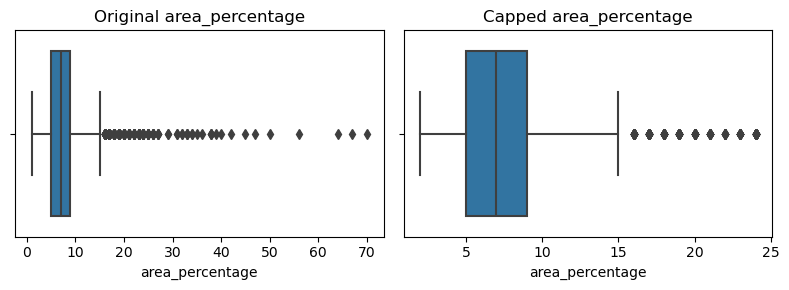

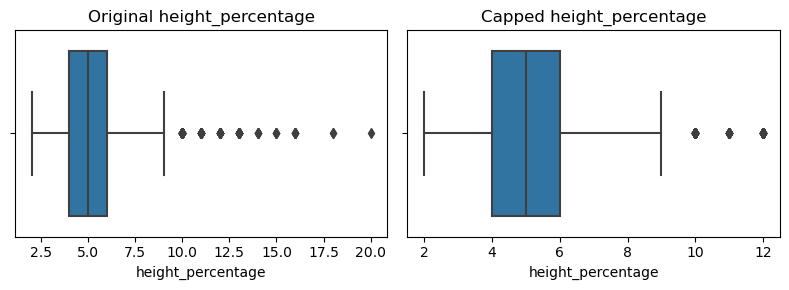

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, make_scorer, classification_report
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Custom OutlierCapper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        sub = X[:, self.col_indices_]
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

# Data Augmentation Function
def augment_data(X, y, num_cols, cat_cols, minority_classes=[0, 2], augmentation_ratio=0.5, noise_scale=0.1, random_state=20):
    np.random.seed(random_state)
    X_aug = X.copy()
    y_aug = y.copy()
    
    # Convert to DataFrame for easier manipulation
    X_df = pd.DataFrame(X_aug, columns=num_cols + cat_cols)
    
    # Augment minority classes
    for cls in minority_classes:
        cls_mask = (y_aug == cls)
        cls_X = X_df[cls_mask]
        cls_y = y_aug[cls_mask]
        n_samples = int(len(cls_X) * augmentation_ratio)
        
        # Numerical features: Add Gaussian noise
        num_noise = np.random.normal(0, noise_scale, (n_samples, len(num_cols)))
        num_aug = cls_X[num_cols].values[:n_samples] + num_noise
        # Clip numerical features to reasonable ranges
        for i, col in enumerate(num_cols):
            if col in ['area_percentage', 'height_percentage']:
                num_aug[:, i] = np.clip(num_aug[:, i], 0, 100)
            elif 'count_' in col:
                num_aug[:, i] = np.clip(num_aug[:, i], 0, None)
                num_aug[:, i] = np.round(num_aug[:, i]).astype(int)
        
        # Categorical features: Randomly swap within the same class
        cat_aug = cls_X[cat_cols].values[:n_samples].copy()
        for col in cat_cols:
            col_idx = X_df.columns.get_loc(col)
            possible_values = X_df.loc[cls_mask, col].unique()
            if len(possible_values) > 1:
                random_choices = np.random.choice(possible_values, size=n_samples, replace=True)
                cat_aug[:, cat_cols.index(col)] = random_choices
        
        # Combine augmented numerical and categorical features
        aug_samples = np.hstack([num_aug, cat_aug])
        X_df_aug = pd.DataFrame(aug_samples, columns=num_cols + cat_cols)
        y_df_aug = np.array([cls] * n_samples)
        
        # Append augmented samples
        X_df = pd.concat([X_df, X_df_aug], ignore_index=True)
        y_aug = np.concatenate([y_aug, y_df_aug])
    
    return X_df, y_aug

# Custom estimator to handle preprocessing and Keras model
class EmbeddedDNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_num_cols, n_cat_cols, cardinalities, flat_dim, cards, n_classes=3, 
                 emb_dim=20, dense1_units=64, dense2_units=32, dropout_rate=0.3, 
                 learning_rate=0.0005, epochs=20, batch_size=128, verbose=0, random_state=20):
        self.n_num_cols = n_num_cols
        self.n_cat_cols = n_cat_cols
        self.cardinalities = cardinalities
        self.flat_dim = flat_dim
        self.cards = cards
        self.n_classes = n_classes
        self.emb_dim = emb_dim
        self.dense1_units = dense1_units
        self.dense2_units = dense2_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y, **fit_params):
        # Initialize preprocessing pipeline
        self.preprocessor_ = ColumnTransformer(
            transformers=[
                ('num', numeric_pipeline, num_columns),
                ('cat', categorical_pipeline, categorical_columns),
                ('high_card', high_card_pipeline, high_card_cat)
            ]
        )
        
        # Transform data
        X_transformed = self.preprocessor_.fit_transform(X)
        
        # Split inputs
        def split_inputs(X_transformed):
            flat = X_transformed[:, :self.n_num_cols]
            cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
            for i in range(cat.shape[1]):
                cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
            cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
            return [flat] + cat_list
        
        X_split = split_inputs(X_transformed)
        
        # Set classes_ attribute
        self.classes_ = np.unique(y)
        
        # Build and compile model
        def build_embedded_dnn():
            flat_in = Input(shape=(self.flat_dim,), name='flat_in')
            cat_in = [Input(shape=(1,), dtype='int32', name=f'cat_in_{i}') for i in range(len(self.cards))]
            
            emb_layers = []
            for i, card in enumerate(self.cards):
                emb = Embedding(input_dim=card, output_dim=self.emb_dim)(cat_in[i])
                emb_flat = Flatten()(emb)
                emb_layers.append(emb_flat)
            
            x = Concatenate()([flat_in] + emb_layers)
            x = Dense(self.dense1_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            x = Dense(self.dense2_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            out = Dense(self.n_classes, activation='softmax')(x)
            
            model = Model(inputs=[flat_in] + cat_in, outputs=out)
            model.compile(optimizer=Adam(learning_rate=self.learning_rate), 
                          loss='sparse_categorical_crossentropy', 
                          metrics=['accuracy'])
            return model
        
        self.model_ = build_embedded_dnn()
        
        # Extract fit parameters
        class_weight = fit_params.get('class_weight', None)
        callbacks = fit_params.get('callbacks', [])
        validation_data = fit_params.get('validation_data', None)
        
        # Prepare validation data if provided
        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_transformed = self.preprocessor_.transform(X_val)
            X_val_split = split_inputs(X_val_transformed)
            validation_data = (X_val_split, y_val)
        
        # Fit model
        history = self.model_.fit(
            X_split,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=class_weight,
            callbacks=callbacks,
            validation_data=validation_data,
            verbose=self.verbose
        )
        
        # Store history for plotting
        self.history_ = history.history
        return self

    def predict(self, X):
        X_transformed = self.preprocessor_.transform(X)
        flat = X_transformed[:, :self.n_num_cols]
        cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
        for i in range(cat.shape[1]):
            cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
        cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
        X_split = [flat] + cat_list
        preds = self.model_.predict(X_split)
        return np.argmax(preds, axis=1)

    def get_params(self, deep=True):
        return {
            'n_num_cols': self.n_num_cols,
            'n_cat_cols': self.n_cat_cols,
            'cardinalities': self.cardinalities,
            'flat_dim': self.flat_dim,
            'cards': self.cards,
            'n_classes': self.n_classes,
            'emb_dim': self.emb_dim,
            'dense1_units': self.dense1_units,
            'dense2_units': self.dense2_units,
            'dropout_rate': self.dropout_rate,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'verbose': self.verbose,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Load data
df = pd.read_csv('train_values.csv')
df_labels = pd.read_csv('train_labels.csv')
df = df.merge(df_labels, on='building_id')

# Analyze class distribution
print("Class distribution before balancing:")
print(pd.Series(df['damage_grade']).value_counts(normalize=True))

# Split data with stratification
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),
    df['damage_grade'],
    test_size=0.3,
    random_state=20,
    shuffle=True,
    stratify=df['damage_grade']
)

# Adjust labels
y_train_adj = y_train - 1
y_val_adj = y_val - 1

# Verify class distribution after split
print("\nClass distribution in training set before balancing:")
print(pd.Series(y_train_adj).value_counts(normalize=True))
print("\nClass distribution in validation set:")
print(pd.Series(y_val_adj).value_counts(normalize=True))

# Define columns
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                      'ground_floor_type', 'other_floor_type', 'position', 
                      'plan_configuration', 'legal_ownership_status']
high_card_cat = ['geo_level_3_id']
num_columns = [col for col in X_train.columns if col not in categorical_columns + high_card_cat]

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(cols=['area_percentage', 'height_percentage'], lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocess training data before SMOTE and augmentation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_columns),
        ('cat', categorical_pipeline, categorical_columns),
        ('high_card', high_card_pipeline, high_card_cat)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=20)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_transformed, y_train_adj)

# Verify class distribution after SMOTE
print("\nClass distribution in training set after SMOTE:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))

# Apply data augmentation to minority classes (labels 0 and 2, corresponding to grades 1 and 3)
X_train_augmented, y_train_augmented = augment_data(
    X_train_balanced,
    y_train_balanced,
    num_columns + high_card_cat,
    categorical_columns,
    minority_classes=[0, 2],  # Grades 1 and 3
    augmentation_ratio=0.5,   # Augment 50% more samples
    noise_scale=0.1,          # Small noise for numerical features
    random_state=20
)

# Verify class distribution after augmentation
print("\nClass distribution in training set after augmentation:")
print(pd.Series(y_train_augmented).value_counts(normalize=True))

# Calculate cardinalities
cardinalities = [int(df[c].astype('category').cat.codes.max()) + 1 for c in categorical_columns]
n_num_cols = len(num_columns) + len(high_card_cat)
n_cat_cols = len(categorical_columns)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_augmented), y=y_train_augmented)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights after augmentation:", class_weight_dict)

# Define scorers for the metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'micro_f1': make_scorer(f1_score, average='micro'),
    'micro_recall': make_scorer(recall_score, average='micro'),
    'micro_precision': make_scorer(precision_score, average='micro')
}

# Define hyperparameter search space
param_dist = {
    'emb_dim': randint(10, 51),
    'dense1_units': randint(32, 129),
    'dense2_units': randint(16, 65),
    'dropout_rate': uniform(0.1, 0.4),
    'learning_rate': uniform(0.0001, 0.005),
    'batch_size': [64, 128, 256]
}

# Initialize custom classifier
model = EmbeddedDNNClassifier(
    n_num_cols=n_num_cols,
    n_cat_cols=n_cat_cols,
    cardinalities=cardinalities,
    flat_dim=n_num_cols,
    cards=cardinalities,
    n_classes=3,
    emb_dim=20,
    dense1_units=64,
    dense2_units=32,
    dropout_rate=0.3,
    learning_rate=0.0005,
    epochs=20,
    batch_size=128,
    verbose=0,
    random_state=20
)

# Perform randomized search
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring=scoring,
    refit='micro_f1',
    cv=3,
    verbose=1,
    n_jobs=1,
    random_state=24,
    error_score='raise'
)

# Fit the search on augmented data
random_search.fit(
    X_train,
    y_train_adj,
    class_weight=class_weight_dict
)

# Print best parameters and cross-validation scores
print("\nBest parameters:", random_search.best_params_)
print("Cross-validation scores for best model:")
for metric in scoring.keys():
    mean_score = random_search.cv_results_[f'mean_test_{metric}'][random_search.best_index_]
    std_score = random_search.cv_results_[f'std_test_{metric}'][random_search.best_index_]
    print(f"{metric}: {mean_score:.4f} (+/- {std_score:.4f})")

# Train best model on full (augmented) training data with plotting
best_model = random_search.best_estimator_
history = best_model.fit(
    X_train,
    y_train_adj,
    epochs=30,
    batch_size=random_search.best_params_['batch_size'],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
    ],
    validation_data=(X_val, y_val_adj),
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_model.history_['loss'], label='Train Loss')
plt.plot(best_model.history_['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(best_model.history_['accuracy'], label='Train Accuracy')
plt.plot(best_model.history_['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on validation set
val_preds = best_model.predict(X_val)
val_preds = val_preds + 1  # Convert back to 1, 2, 3
val_y = y_val  # Original labels (1, 2, 3)

# Compute overall metrics
print("\nValidation set metrics (overall):")
print(f"Accuracy: {accuracy_score(val_y, val_preds):.4f}")
print(f"Micro-F1: {f1_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Recall: {recall_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Precision: {precision_score(val_y, val_preds, average='micro'):.4f}")

# Compute per-class metrics
print("\nPer-class metrics:")
print(classification_report(val_y, val_preds, target_names=['Grade 1', 'Grade 2', 'Grade 3']))

# Predict on test set
try:
    test_df = pd.read_csv('test_values.csv')
    ids = test_df['building_id']
    X_test = test_df[X_train.columns]
    print("X_test columns:", X_test.columns.tolist())
    test_preds = best_model.predict(X_test)
    test_preds = test_preds + 1

    pd.DataFrame({
        'building_id': ids,
        'damage_grade': test_preds
    }).to_csv('tuned_embedded_dnn_submission_balanced_augmented.csv', index=False)
    print("Submission saved to 'tuned_embedded_dnn_submission_balanced_augmented.csv'")
except FileNotFoundError:
    print("Error: 'test_values.csv' not found. Please ensure the file is in the working directory.")

# Visualize outlier capping
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    qs = X[['area_percentage', 'height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    for col in ['area_percentage', 'height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

sample = df[['area_percentage', 'height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)
for col in ['area_percentage', 'height_percentage']:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"Original {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"Capped {col}")
    plt.tight_layout()
    plt.show()